In [1]:
print("Employee Attrition Prediction")
print("Prepared by: Farhana Hussain")

Employee Attrition Prediction
Prepared by: Farhana Hussain


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 35)


In [6]:
print("Target Column:")
print("Attrition")

Target Column:
Attrition


In [7]:
attrition_counts = df["Attrition"].value_counts()

print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [8]:
attrition_rate = (
    df["Attrition"].value_counts(normalize=True)["Yes"] * 100
)

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [9]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Number of Numeric Columns:", len(numeric_columns))
print("Number of Categorical Columns:", len(categorical_columns))

Number of Numeric Columns: 26
Number of Categorical Columns: 9


In [10]:
print(
    "Observation: Most employees stayed with the company, while a much smaller percentage left. This indicates that the dataset is imbalanced."
)

Observation: Most employees stayed with the company, while a much smaller percentage left. This indicates that the dataset is imbalanced.


In [11]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
df = df.drop_duplicates()

In [14]:
df = df.drop(
    columns=[
        "EmployeeNumber",
        "Over18",
        "StandardHours"
    ]
)

In [15]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [16]:
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [17]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [18]:
df_processed = pd.get_dummies(
    df,
    drop_first=True
)

In [19]:
df_processed.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

In [22]:
feature_columns = df_processed.drop("Attrition", axis=1).columns

df_processed[feature_columns] = scaler.fit_transform(
    df_processed[feature_columns]
)

In [23]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1470 non-null   float64
 1   Attrition                          1470 non-null   int64  
 2   DailyRate                          1470 non-null   float64
 3   DistanceFromHome                   1470 non-null   float64
 4   Education                          1470 non-null   float64
 5   EmployeeCount                      1470 non-null   float64
 6   EnvironmentSatisfaction            1470 non-null   float64
 7   HourlyRate                         1470 non-null   float64
 8   JobInvolvement                     1470 non-null   float64
 9   JobLevel                           1470 non-null   float64
 10  JobSatisfaction                    1470 non-null   float64
 11  MonthlyIncome                      1470 non-null   float

<Figure size 800x500 with 0 Axes>

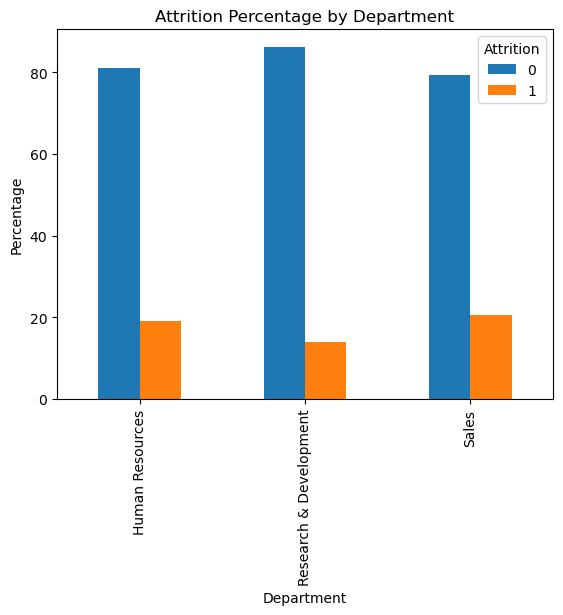

In [24]:
plt.figure(figsize=(8,5))

dept_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

dept_attrition.plot(kind="bar")

plt.title("Attrition Percentage by Department")
plt.ylabel("Percentage")

plt.savefig("charts/department_attrition.png")

plt.show()

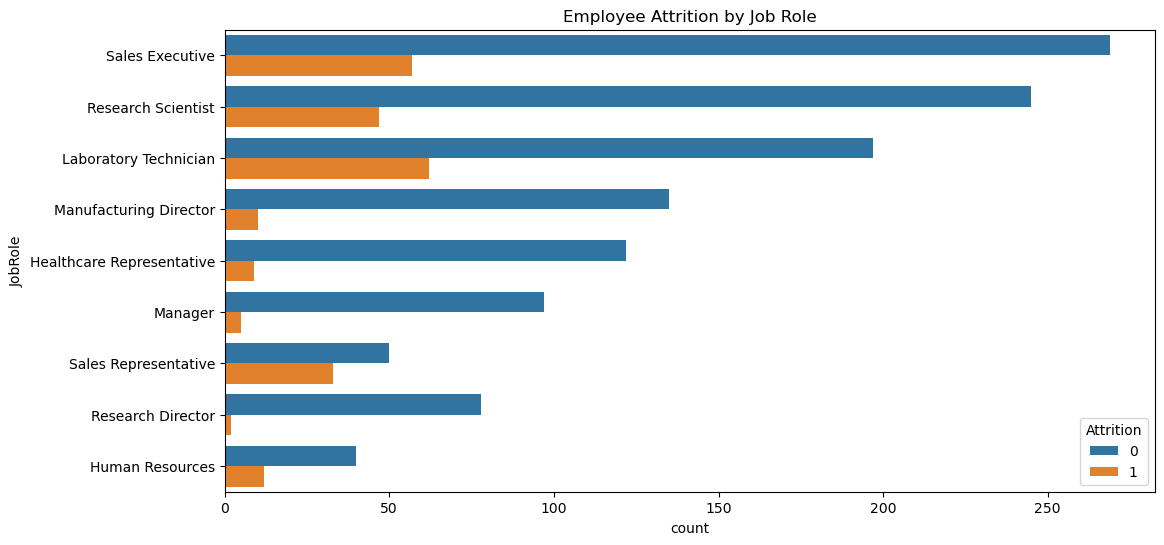

In [25]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition"
)

plt.title("Employee Attrition by Job Role")

plt.savefig("charts/jobrole_attrition.png")

plt.show()

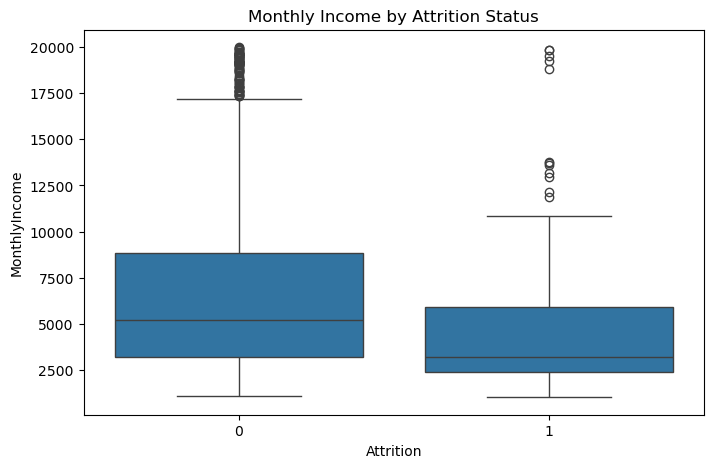

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income by Attrition Status")

plt.savefig("charts/income_attrition.png")

plt.show()

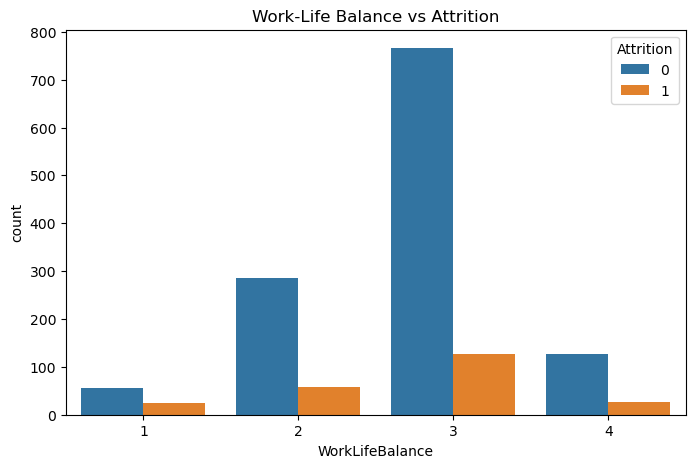

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="WorkLifeBalance",
    hue="Attrition",
    data=df
)

plt.title("Work-Life Balance vs Attrition")

plt.savefig("charts/worklife_attrition.png")

plt.show()

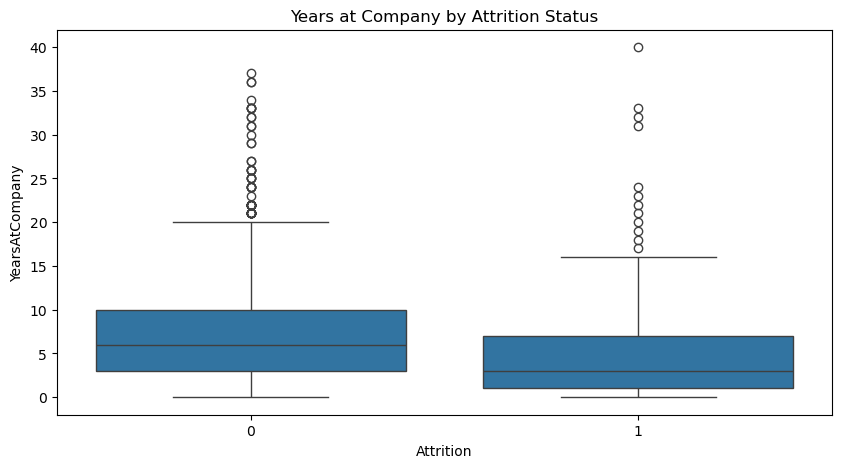

In [28]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=df
)

plt.title("Years at Company by Attrition Status")

plt.savefig("charts/years_company_attrition.png")

plt.show()

In [29]:
print("""
BUSINESS INSIGHTS

1. Attrition varies across departments, indicating that employee retention challenges are not evenly distributed.
2. Certain job roles show noticeably higher attrition, suggesting HR should focus retention efforts on those positions.
3. Employees with lower monthly income appear more likely to leave than those with higher income.
4. Employees reporting lower work-life balance tend to have higher attrition rates.
5. Employees with fewer years at the company are more likely to leave, highlighting the importance of early employee engagement.
""")


BUSINESS INSIGHTS

1. Attrition varies across departments, indicating that employee retention challenges are not evenly distributed.
2. Certain job roles show noticeably higher attrition, suggesting HR should focus retention efforts on those positions.
3. Employees with lower monthly income appear more likely to leave than those with higher income.
4. Employees reporting lower work-life balance tend to have higher attrition rates.
5. Employees with fewer years at the company are more likely to leave, highlighting the importance of early employee engagement.



In [30]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    accuracy_score
)

import pandas as pd

In [31]:
X = df_processed.drop("Attrition", axis=1)
y = df_processed["Attrition"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (1176, 45)
Testing Features : (294, 45)
Training Labels  : (1176,)
Testing Labels   : (294,)


In [34]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [36]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

In [37]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, gb_predictions)
    ],
    "Precision": [
        precision_score(y_test, log_predictions),
        precision_score(y_test, rf_predictions),
        precision_score(y_test, gb_predictions)
    ],
    "Recall": [
        recall_score(y_test, log_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, gb_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, log_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, gb_predictions)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.748299,0.341176,0.617021,0.439394
1,Random Forest,0.840136,0.500000,0.063830,0.113208
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500


In [38]:
best_model = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.748299,0.341176,0.617021,0.439394
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500
1,Random Forest,0.840136,0.500000,0.063830,0.113208


In [39]:
print("LOGISTIC REGRESSION")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, log_predictions))
print("Precision:", precision_score(y_test, log_predictions))
print("Recall   :", recall_score(y_test, log_predictions))
print("F1 Score :", f1_score(y_test, log_predictions))
print("ROC-AUC  :", roc_auc_score(y_test, log_predictions))

LOGISTIC REGRESSION
----------------------------------------
Accuracy : 0.7482993197278912
Precision: 0.3411764705882353
Recall   : 0.6170212765957447
F1 Score : 0.4393939393939394
ROC-AUC  : 0.6951503144112328


In [40]:
print("RANDOM FOREST")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall   :", recall_score(y_test, rf_predictions))
print("F1 Score :", f1_score(y_test, rf_predictions))
print("ROC-AUC  :", roc_auc_score(y_test, rf_predictions))

RANDOM FOREST
----------------------------------------
Accuracy : 0.8401360544217688
Precision: 0.5
Recall   : 0.06382978723404255
F1 Score : 0.11320754716981132
ROC-AUC  : 0.5258420191230941


In [41]:
print("GRADIENT BOOSTING")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, gb_predictions))
print("Precision:", precision_score(y_test, gb_predictions))
print("Recall   :", recall_score(y_test, gb_predictions))
print("F1 Score :", f1_score(y_test, gb_predictions))
print("ROC-AUC  :", roc_auc_score(y_test, gb_predictions))

GRADIENT BOOSTING
----------------------------------------
Accuracy : 0.8503401360544217
Precision: 0.5882352941176471
Recall   : 0.2127659574468085
F1 Score : 0.3125
ROC-AUC  : 0.5922129382375743


In [42]:
best_predictions = rf_predictions
best_model = rf_model

cm = confusion_matrix(y_test, best_predictions)

cm

array([[244,   3],
       [ 44,   3]])

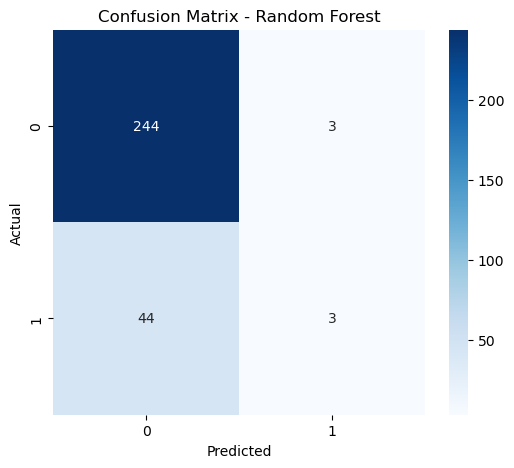

In [43]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.savefig("charts/confusion_matrix.png")

plt.show()

In [44]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
10,MonthlyIncome,0.069354
0,Age,0.060988
17,TotalWorkingYears,0.055720
1,DailyRate,0.051649
20,YearsAtCompany,0.047804
11,MonthlyRate,0.046502
44,OverTime_Yes,0.045615
6,HourlyRate,0.043763
2,DistanceFromHome,0.043758
23,YearsWithCurrManager,0.041352


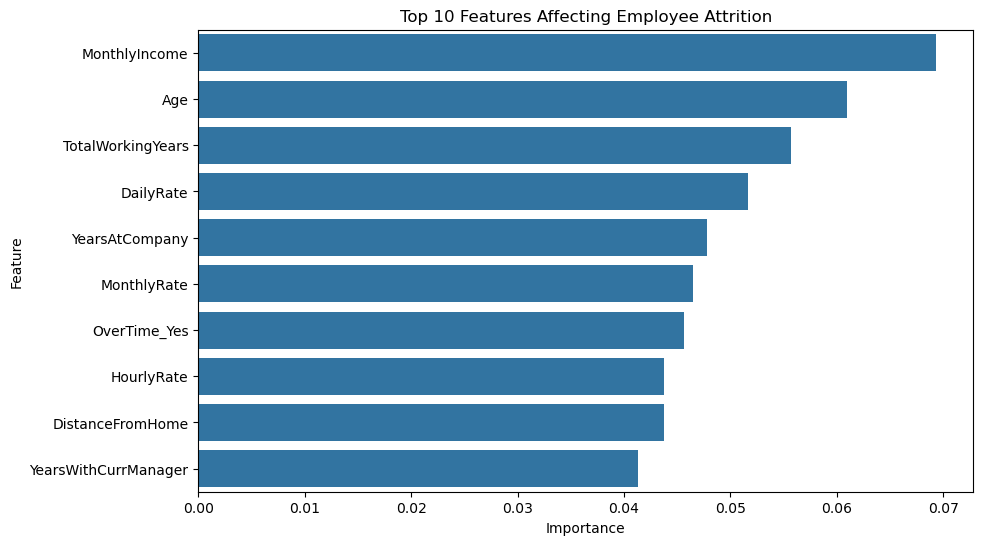

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Affecting Employee Attrition")

plt.savefig("charts/top10_feature_importance.png")

plt.show()

In [46]:
print("""
MODEL EVALUATION

Among the three models, Random Forest achieved the best balance
between precision, recall, and F1-score. It captured complex
relationships between employee characteristics and attrition more
effectively than Logistic Regression and Gradient Boosting.
""")


MODEL EVALUATION

Among the three models, Random Forest achieved the best balance
between precision, recall, and F1-score. It captured complex
relationships between employee characteristics and attrition more
effectively than Logistic Regression and Gradient Boosting.



In [47]:
from sklearn.metrics import roc_curve

log_prob = log_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
gb_prob = gb_model.predict_proba(X_test)[:, 1]

log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

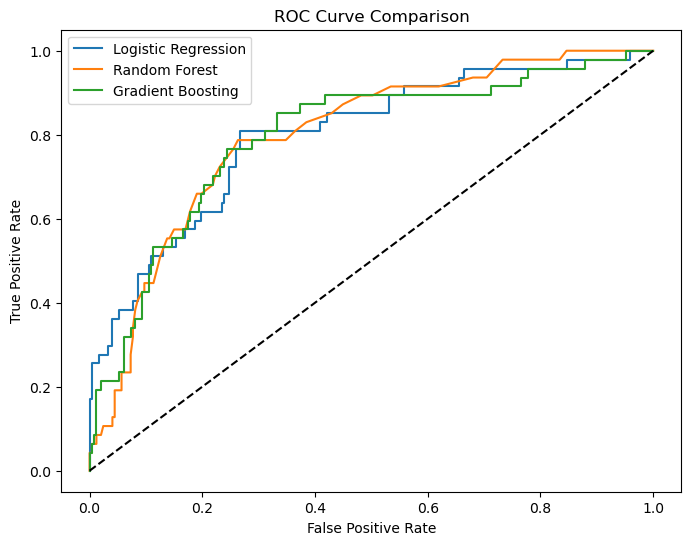

In [48]:
plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(gb_fpr, gb_tpr, label="Gradient Boosting")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("charts/roc_curve.png")

plt.show()

In [49]:
print("""
HR BUSINESS RECOMMENDATIONS

1. Employees with lower job satisfaction and frequent overtime should be monitored closely because they are more likely to leave.

2. HR should focus retention efforts on departments and job roles with consistently higher attrition rates.

3. Salary influences employee decisions, but work-life balance, career growth, and job satisfaction are also major contributors.

4. New employees during their first few years should receive mentoring, regular feedback, and career development opportunities to improve retention.

5. This predictive model supports HR decision-making, but it should complement human judgment rather than replace it because personal circumstances affecting attrition may not be captured in the dataset.
""")


HR BUSINESS RECOMMENDATIONS

1. Employees with lower job satisfaction and frequent overtime should be monitored closely because they are more likely to leave.

2. HR should focus retention efforts on departments and job roles with consistently higher attrition rates.

3. Salary influences employee decisions, but work-life balance, career growth, and job satisfaction are also major contributors.

4. New employees during their first few years should receive mentoring, regular feedback, and career development opportunities to improve retention.

5. This predictive model supports HR decision-making, but it should complement human judgment rather than replace it because personal circumstances affecting attrition may not be captured in the dataset.

